# What is the dependency on the source redshift?
--------

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from get_model_probabilities import *

import scienceplots
plt.style.use(["science","grid"])

Source redshift:1.36


In [3]:

ifilter = 'concat'

all_models = glob(f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth")[:5]
imonte=2


In [11]:



output_name = f"pickles/source_redshift_{ifilter}_test.pkl"

if os.path.isfile( output_name ):
    all_results = pkl.load(open(output_name,"rb"))
else:
    all_results = {}
    
domain = {
    'tgt':'darkskies_obs',
    'src':'bahamas_obs'
}
args.jwst_filter = 'concat'
args.apply_intrinsic_ell = 1.

for this_zs in [1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0]:
    
    if this_zs in all_results.keys():
        continue
    all_results[this_zs] = {}
    
    
    
    for imodel in tqdm(all_models):

        seed = imodel.split('_')[-7]

        print(seed)

        if f"seed_{seed}" in all_results[this_zs].keys():
            continue
        
        zs = {
        'concat':this_zs
        }

        args.ignore_dataset = [''] # Althopiugh i ignored during training i want to see duringn testing.
        all_results[this_zs][f"seed_{seed}"]  = {'src':[],'tgt':[]}

        args.log_mass_cut=0. # Make sure i test on equal mass clusters

        args.unbalance = False
        args.zs = zs['concat']
        
        for i in range(imonte):
            for idomain in domain.keys():

                target_domain = domain[idomain]
                results = get_probabilities( 
                        target_domain,
                        [imodel],
                        args,
                        quiet=True
                )
                del results['data_loaders']

                all_results[this_zs][f"seed_{seed}"][idomain].append( results )

    pkl.dump(all_results, open(output_name,"wb"))


PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/source_redshift.pdf'.


0

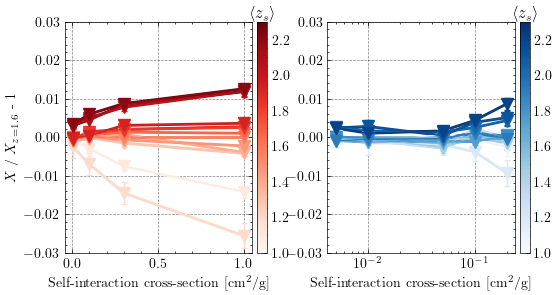

In [30]:
config='baha2dark'
filter_list  = ['concat']
cdm = 5e-3



domain = {
    'tgt':'darkskies_obs',
    'src':'bahamas_obs'
}


source_tests = f"pickles/source_redshift_{ifilter}_test.pkl"

all_tests = pkl.load(open(source_tests,'rb'))


fig, axarr = plt.subplots(1,2, figsize=(6,3))
fig.subplots_adjust(wspace=0.3)
ax = axarr[0]


color = {
        'src':colourFromRange([-1,len(all_tests.keys())], cmap='Reds'),
        'tgt':colourFromRange([-1,len(all_tests.keys())], cmap='Blues')
    }

fid =  all_tests[1.6]

all_zs = np.array(list(all_tests.keys()))
for izs, isource_redshift in enumerate(all_zs):
   
    
    all_results = all_tests[isource_redshift]


    

    for itgt, target in enumerate(['src','tgt']):
        all_thresholds = []
        ax = axarr[itgt]
        for imodel in all_results.keys():
            
            seed = float(imodel.split('_')[1])
  
            tgt = get_threshold_for_cross( 
                all_results[imodel][target], 
                mass_cut=None, 
                dataset=domain[target].split('_')[0],
                quiet=False)

            ref = get_threshold_for_cross( 
                fid[imodel][target], 
                mass_cut=None, 
                dataset=domain[target].split('_')[0],
                quiet=False)
            
            all_thresholds.append(tgt['thresholds']/ref['thresholds'])
            
        all_thresholds = np.array(all_thresholds)
        means = np.nanmean(all_thresholds,axis=0)
        errors = np.std(all_thresholds,axis=0) / np.sqrt(all_thresholds.shape[0]) 
        




        tgt['cross_sections'][0] += cdm
        ax.errorbar( tgt['cross_sections'], 
                    means-1,
                    errors,
                    fmt='-v', label=f"$z_s$={isource_redshift}", 
                    capsize=2,
                    markersize=8, color=color[target][izs])
        ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]")
        #ax.legend(loc=3, ncols=2)
        
        points = np.column_stack([tgt['cross_sections'], means-1])          # shape (N, 2)
        segments = np.stack([points[:-1], points[1:]], axis=1)  # shape (N-1, 2, 2)

        lc = LineCollection(
                segments,
                cmap=color[target].cmap,
                norm=plt.Normalize(all_zs.min(), all_zs.max()),
                linewidths=2
            )

        lc.set_array(np.full(segments.shape[0], isource_redshift))
        im2 = ax.add_collection(lc)
        
        
        if izs == len(all_results.keys())-1:
            divider = make_axes_locatable(ax)
            cax = divider.append_axes('right', size='5%', pad=0.05)
            fig.colorbar(im2, cax=cax, orientation='vertical')
            ax.text(1.06,1.02,"$\langle z_s \\rangle$",transform=ax.transAxes,fontsize=12, ha='center')
        ax.set_ylim(-0.03,0.03)
    #ax.set_xscale('log')

    ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]")
    #ax.set_ylabel("Model threshold output")

    #
    #ax.set_xlim(3e-3,1)
    
    #ax.text(0.05,0.85,f"{isource_redshift}", transform=ax.transAxes,fontsize=12)
    ax.set_xscale('log')
#plot_observations( "pickles/model_on_data.pkl", 'concat', ax=ax, correction=3.6, fill_args={'alpha':0.2} )

    
axarr[0].set_ylabel("$X$ / $X_{z=1.6}$ - 1")
fname = "plots/source_redshift.pdf"
plt.savefig(fname)
os.system(f"pdfcrop {fname} {fname}")